In [10]:
#step-1
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

conn = sqlite3.connect("../data/db/bluestock_mf.db")

nav_df = pd.read_sql("SELECT amfi_code, nav_date, nav FROM fact_nav ORDER BY amfi_code, nav_date", conn)
nav_df["nav_date"] = pd.to_datetime(nav_df["nav_date"])
nav_df = nav_df.rename(columns={"nav": "nav_value"})  # keep rest of code consistent

fund_df = pd.read_sql("SELECT * FROM dim_fund", conn)
print(fund_df.columns.tolist())

print(nav_df.shape)
nav_df.head()

['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'fund_manager', 'risk_category']
(64320, 3)


,amfi_code,nav_date,nav_value
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
#step-1
nav_df = nav_df.sort_values(["amfi_code", "nav_date"])
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav_value"].pct_change()

# drop first row of each scheme (NaN return)
returns_df = nav_df.dropna(subset=["daily_return"]).copy()

print("Total return rows:", len(returns_df))
print("Schemes covered:", returns_df["amfi_code"].nunique())
returns_df["daily_return"].describe()

Total return rows: 64280
Schemes covered: 40


count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

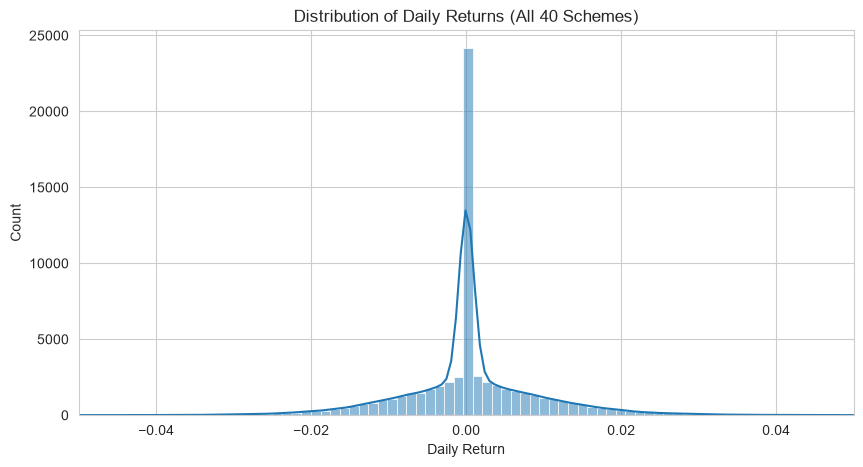


Extreme outlier days (>|20%|): 0


,amfi_code,nav_date,daily_return


In [4]:
#step-1
plt.figure(figsize=(10,5))
sns.histplot(returns_df["daily_return"], bins=100, kde=True)
plt.title("Distribution of Daily Returns (All 40 Schemes)")
plt.xlabel("Daily Return")
plt.xlim(-0.05, 0.05)  # zoom in, ignore extreme outliers
plt.savefig("../charts/daily_returns_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# sanity check: flag any extreme outlier returns (likely data errors)
outliers = returns_df[returns_df["daily_return"].abs() > 0.20]
print(f"\nExtreme outlier days (>|20%|): {len(outliers)}")
outliers[["amfi_code","nav_date","daily_return"]].head(10)

In [12]:
#step-2
def calc_cagr(nav_series, dates, years):
    """CAGR over the last `years` years, using latest available NAV as end point."""
    end_date = dates.max()
    start_date = end_date - pd.DateOffset(years=years)
    
    window = nav_series[dates >= start_date]
    window_dates = dates[dates >= start_date]
    
    if len(window) < 2:
        return np.nan
    
    nav_start = window.iloc[0]
    nav_end = window.iloc[-1]
    n_years = (window_dates.iloc[-1] - window_dates.iloc[0]).days / 365.25
    
    if n_years <= 0 or nav_start <= 0:
        return np.nan
    
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_records = []
for code, grp in nav_df.groupby("amfi_code"):
    grp = grp.sort_values("nav_date")
    record = {"amfi_code": code}
    for yrs, label in [(1, "cagr_1yr"), (3, "cagr_3yr"), (5, "cagr_5yr")]:
        record[label] = calc_cagr(grp["nav_value"], grp["nav_date"], yrs)
    cagr_records.append(record)

cagr_df = pd.DataFrame(cagr_records)
cagr_df = cagr_df.merge(fund_df[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
cagr_df = cagr_df[["amfi_code", "scheme_name", "category", "cagr_1yr", "cagr_3yr", "cagr_5yr"]]

cagr_df = cagr_df.sort_values("cagr_3yr", ascending=False)
cagr_df.head(10)

,amfi_code,scheme_name,category,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,Axis Midcap Fund - Regular - Growth,Equity,0.222779,0.351025,0.282144
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.203760,0.339920,0.309741
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.130738,0.324789,0.232951
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.532772,0.324340,0.301232
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.296277,0.317692,0.328274
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.604893,0.304486,0.258047
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.266776,0.295751,0.309075
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.397838,0.291714,0.319495
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.479638,0.289602,0.235384
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,0.651955,0.269935,0.322874


In [13]:
#step-3
Rf = 0.065  # RBI repo rate proxy, annualized

sharpe_records = []
for code, grp in returns_df.groupby("amfi_code"):
    daily_returns = grp["daily_return"]
    mean_daily = daily_returns.mean()
    std_daily = daily_returns.std()
    
    annualized_return = mean_daily * 252
    annualized_std = std_daily * np.sqrt(252)
    
    if annualized_std == 0 or pd.isna(annualized_std):
        sharpe = np.nan
    else:
        sharpe = (annualized_return - Rf) / annualized_std
    
    sharpe_records.append({
        "amfi_code": code,
        "annualized_return": annualized_return,
        "annualized_std": annualized_std,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df = sharpe_df.merge(fund_df[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
sharpe_df = sharpe_df[["amfi_code", "scheme_name", "category", "annualized_return", "annualized_std", "sharpe_ratio"]]

sharpe_df["sharpe_rank"] = sharpe_df["sharpe_ratio"].rank(ascending=False)
sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)

sharpe_df.head(10)

,amfi_code,scheme_name,category,annualized_return,annualized_std,sharpe_ratio,sharpe_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.193454,0.120250,1.068224,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.194910,0.134543,0.965561,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.202531,0.149645,0.919047,3.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.209246,0.163311,0.883256,4.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.165188,0.116365,0.860977,5.0
38,149323,DSP Midcap Fund - Regular - Growth,Equity,0.190123,0.150229,0.832885,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.194558,0.160291,0.808268,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,0.155896,0.119781,0.758851,8.0
16,119094,Axis Midcap Fund - Regular - Growth,Equity,0.184990,0.164246,0.730547,9.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.153472,0.123321,0.717409,10.0


In [14]:

#step-4
sortino_records = []
for code, grp in returns_df.groupby("amfi_code"):
    daily_returns = grp["daily_return"]
    mean_daily = daily_returns.mean()
    
    downside_returns = daily_returns[daily_returns < 0]
    downside_std = downside_returns.std()
    
    annualized_return = mean_daily * 252
    annualized_downside_std = downside_std * np.sqrt(252)
    
    if annualized_downside_std == 0 or pd.isna(annualized_downside_std):
        sortino = np.nan
    else:
        sortino = (annualized_return - Rf) / annualized_downside_std
    
    sortino_records.append({
        "amfi_code": code,
        "annualized_return": annualized_return,
        "downside_std": annualized_downside_std,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_records)
sortino_df = sortino_df.merge(fund_df[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
sortino_df = sortino_df[["amfi_code", "scheme_name", "category", "annualized_return", "downside_std", "sortino_ratio"]]

sortino_df["sortino_rank"] = sortino_df["sortino_ratio"].rank(ascending=False)
sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)

sortino_df.head(10)

,amfi_code,scheme_name,category,annualized_return,downside_std,sortino_ratio,sortino_rank
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.193454,0.086168,1.490739,1.0
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.194910,0.087806,1.479503,2.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.202531,0.101663,1.352815,3.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.165188,0.077576,1.291483,4.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.209246,0.112180,1.285843,5.0
38,149323,DSP Midcap Fund - Regular - Growth,Equity,0.190123,0.107145,1.167793,6.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.194558,0.113229,1.144216,7.0
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,0.155896,0.082717,1.098880,8.0
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.216398,0.141857,1.067256,9.0
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.151899,0.081675,1.063964,10.0


In [15]:
cur = conn.cursor()
cur.execute("PRAGMA table_info(fact_performance)")
for row in cur.fetchall():
    print(row)

print("---")
# also check if there's a benchmark table
cur.execute("SELECT name FROM sqlite_master WHERE type='table'")
for row in cur.fetchall():
    print(row)

(0, 'amfi_code', 'TEXT', 0, None, 0)
(1, 'return_1yr_pct', 'REAL', 0, None, 0)
(2, 'return_3yr_pct', 'REAL', 0, None, 0)
(3, 'return_5yr_pct', 'REAL', 0, None, 0)
(4, 'sharpe_ratio', 'REAL', 0, None, 0)
(5, 'sortino_ratio', 'REAL', 0, None, 0)
(6, 'alpha', 'REAL', 0, None, 0)
(7, 'beta', 'REAL', 0, None, 0)
(8, 'max_drawdown_pct', 'REAL', 0, None, 0)
---
('fact_transactions',)
('dim_fund',)
('fact_nav',)
('fact_performance',)
('fact_aum',)


In [16]:
import pandas as pd
bench_raw = pd.read_csv("../data/raw/10_benchmark_indices.csv")
print(bench_raw.columns.tolist())
bench_raw.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
print(bench_raw["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [18]:
# step-5 prep benchmark returns
bench_raw["date"] = pd.to_datetime(bench_raw["date"])
nifty100 = bench_raw[bench_raw["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100.dropna(subset=["bench_return"])[["date", "bench_return"]].rename(columns={"date": "nav_date"})

alpha_beta_records = []
for code, grp in returns_df.groupby("amfi_code"):
    fund_ret = grp[["nav_date", "daily_return"]].copy()
    merged = fund_ret.merge(nifty100, on="nav_date", how="inner")
    
    if len(merged) < 30:  # need reasonable sample size
        alpha_beta_records.append({"amfi_code": code, "alpha": np.nan, "beta": np.nan, "r_value": np.nan})
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged["bench_return"], merged["daily_return"]
    )
    
    beta = slope
    alpha = intercept * 252  # annualized alpha
    
    alpha_beta_records.append({
        "amfi_code": code,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_value ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_records)
alpha_beta_df = alpha_beta_df.merge(fund_df[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
alpha_beta_df = alpha_beta_df[["amfi_code", "scheme_name", "category", "alpha", "beta", "r_squared"]]

alpha_beta_df["alpha_rank"] = alpha_beta_df["alpha"].rank(ascending=False)
alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)

alpha_beta_df.head(10)

,amfi_code,scheme_name,category,alpha,beta,r_squared,alpha_rank
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.303370,-0.023196,1.414258e-04,1.0
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,0.300579,0.011455,3.532991e-05,2.0
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.292636,0.000549,1.345534e-07,3.0
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.282704,0.018134,1.748889e-04,4.0
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.273305,-0.022830,3.430543e-04,5.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.271954,0.005104,1.206652e-05,6.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.269838,0.023684,4.625437e-04,7.0
38,149323,DSP Midcap Fund - Regular - Growth,Equity,0.265986,-0.002523,3.357978e-06,8.0
16,119094,Axis Midcap Fund - Regular - Growth,Equity,0.260767,-0.066265,1.936879e-03,9.0
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.232010,-0.031751,8.869789e-04,10.0


In [19]:
#step-6
drawdown_records = []
for code, grp in nav_df.groupby("amfi_code"):
    grp = grp.sort_values("nav_date").copy()
    grp["running_max"] = grp["nav_value"].cummax()
    grp["drawdown"] = grp["nav_value"] / grp["running_max"] - 1
    
    max_dd = grp["drawdown"].min()
    max_dd_date = grp.loc[grp["drawdown"].idxmin(), "nav_date"]
    
    # find the peak date before the max drawdown trough
    peak_date = grp[grp["nav_date"] <= max_dd_date].loc[
        grp[grp["nav_date"] <= max_dd_date]["nav_value"].idxmax(), "nav_date"
    ]
    
    drawdown_records.append({
        "amfi_code": code,
        "max_drawdown_pct": max_dd,
        "peak_date": peak_date,
        "trough_date": max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_records)
drawdown_df = drawdown_df.merge(fund_df[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left")
drawdown_df = drawdown_df[["amfi_code", "scheme_name", "category", "max_drawdown_pct", "peak_date", "trough_date"]]

drawdown_df["max_dd_rank"] = drawdown_df["max_drawdown_pct"].rank(ascending=False)  # smaller (less negative) drawdown = better = higher rank
drawdown_df = drawdown_df.sort_values("max_drawdown_pct")

drawdown_df.head(10)

,amfi_code,scheme_name,category,max_drawdown_pct,peak_date,trough_date,max_dd_rank
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-0.525742,2023-01-17,2025-10-28,40.0
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,-0.516778,2025-05-22,2026-05-11,39.0
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-0.354469,2024-11-21,2026-05-11,38.0
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,-0.311719,2024-05-03,2025-01-03,37.0
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-0.287060,2024-08-28,2025-05-14,36.0
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-0.280011,2025-01-07,2026-04-27,35.0
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,-0.247344,2022-03-30,2022-09-15,34.0
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,-0.240035,2023-11-09,2024-10-17,33.0
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-0.233449,2025-04-09,2026-02-20,32.0
15,119093,Axis Bluechip Fund - Direct - Growth,Equity,-0.217514,2022-02-24,2023-05-22,31.0


In [20]:
#step-7
# merge all metrics into one table
scorecard_df = cagr_df[["amfi_code", "scheme_name", "category", "cagr_3yr"]].copy()
scorecard_df = scorecard_df.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code", how="left")
scorecard_df = scorecard_df.merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code", how="left")
scorecard_df = scorecard_df.merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code", how="left")
scorecard_df = scorecard_df.merge(fund_df[["amfi_code", "expense_ratio_pct"]], on="amfi_code", how="left")

# rank each metric as percentile, where 1.0 = best fund on that metric
scorecard_df["rank_3yr_return"] = scorecard_df["cagr_3yr"].rank(ascending=True, pct=True)
scorecard_df["rank_sharpe"] = scorecard_df["sharpe_ratio"].rank(ascending=True, pct=True)
scorecard_df["rank_alpha"] = scorecard_df["alpha"].rank(ascending=True, pct=True)
scorecard_df["rank_max_dd"] = scorecard_df["max_drawdown_pct"].rank(ascending=True, pct=True)  # less negative = higher value = better
scorecard_df["rank_expense"] = scorecard_df["expense_ratio_pct"].rank(ascending=False, pct=True)  # lower expense = better

scorecard_df["fund_score"] = (
    0.30 * scorecard_df["rank_3yr_return"] +
    0.25 * scorecard_df["rank_sharpe"] +
    0.20 * scorecard_df["rank_alpha"] +
    0.15 * scorecard_df["rank_expense"] +
    0.10 * scorecard_df["rank_max_dd"]
) * 100

scorecard_df = scorecard_df.sort_values("fund_score", ascending=False)
scorecard_df[["amfi_code", "scheme_name", "category", "fund_score", "cagr_3yr", "sharpe_ratio", "alpha", "expense_ratio_pct", "max_drawdown_pct"]].head(10)

,amfi_code,scheme_name,category,fund_score,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown_pct
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,86.2500,0.339920,1.068224,0.269838,1.46,-0.112657
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,82.8750,0.317692,0.883256,0.292636,1.36,-0.181885
6,120843,Kotak Flexicap Fund - Regular - Growth,Equity,82.0000,0.295751,0.965561,0.273305,1.45,-0.129740
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,80.7500,0.324340,0.808268,0.271954,1.38,-0.162172
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,79.3750,0.324789,0.714682,0.211948,0.80,-0.125883
0,119094,Axis Midcap Fund - Regular - Growth,Equity,78.2500,0.351025,0.730547,0.260767,1.38,-0.209609
5,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,74.1875,0.304486,0.860977,0.232010,1.54,-0.150124
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,73.6875,0.291714,0.919047,0.282704,1.60,-0.163967
11,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,68.0000,0.266631,0.711690,0.303370,1.43,-0.287060
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,67.5625,0.289602,0.717409,0.213998,1.60,-0.112916


In [21]:
import os
os.makedirs("../reports", exist_ok=True)

scorecard_df.to_csv("../reports/fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

print("Saved fund_scorecard.csv:", scorecard_df.shape)
print("Saved alpha_beta.csv:", alpha_beta_df.shape)

Saved fund_scorecard.csv: (40, 14)
Saved alpha_beta.csv: (40, 7)


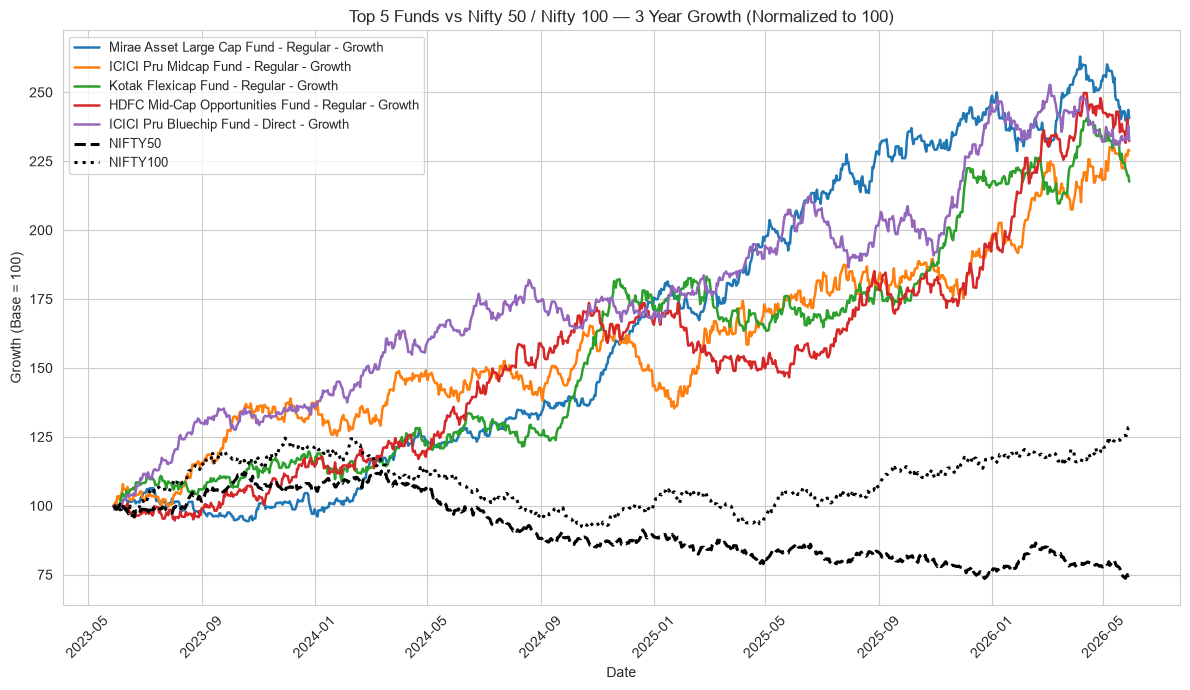

In [22]:
#step-8
# get top 5 funds by fund_score
top5_codes = scorecard_df.head(5)["amfi_code"].tolist()
top5_names = scorecard_df.head(5)["scheme_name"].tolist()

# build cumulative growth series for top 5 funds (normalized to 100 at start)
fig, ax = plt.subplots(figsize=(12, 7))

for code, name in zip(top5_codes, top5_names):
    fund_nav = nav_df[nav_df["amfi_code"] == code].sort_values("nav_date").copy()
    fund_nav = fund_nav[fund_nav["nav_date"] >= (fund_nav["nav_date"].max() - pd.DateOffset(years=3))]
    fund_nav["normalized"] = fund_nav["nav_value"] / fund_nav["nav_value"].iloc[0] * 100
    ax.plot(fund_nav["nav_date"], fund_nav["normalized"], label=name, linewidth=1.8)

# add Nifty 50 and Nifty 100, normalized the same way, over the same 3yr window
cutoff = nav_df["nav_date"].max() - pd.DateOffset(years=3)

for idx_name, style in [("NIFTY50", "--"), ("NIFTY100", ":")]:
    idx_data = bench_raw[bench_raw["index_name"] == idx_name].sort_values("date").copy()
    idx_data = idx_data[idx_data["date"] >= cutoff]
    idx_data["normalized"] = idx_data["close_value"] / idx_data["close_value"].iloc[0] * 100
    ax.plot(idx_data["date"], idx_data["normalized"], label=idx_name, linewidth=2.2, linestyle=style, color="black")

ax.set_title("Top 5 Funds vs Nifty 50 / Nifty 100 — 3 Year Growth (Normalized to 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth (Base = 100)")
ax.legend(loc="upper left", fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../charts/benchmark_comparison_top5.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# tracking error = std(fund_return - benchmark_return) * sqrt(252)
nifty100_ret = nifty100.rename(columns={"bench_return": "nifty100_return"})

tracking_error_records = []
for code, name in zip(top5_codes, top5_names):
    fund_ret = returns_df[returns_df["amfi_code"] == code][["nav_date", "daily_return"]]
    merged = fund_ret.merge(nifty100_ret, on="nav_date", how="inner")
    excess = merged["daily_return"] - merged["nifty100_return"]
    tracking_error = excess.std() * np.sqrt(252)
    tracking_error_records.append({"amfi_code": code, "scheme_name": name, "tracking_error": tracking_error})

tracking_error_df = pd.DataFrame(tracking_error_records)
tracking_error_df

,amfi_code,scheme_name,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.189664
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.231968
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206425
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.191587


In [24]:
tracking_error_df.to_csv("../reports/tracking_error.csv", index=False)
print("All Day 4 deliverables saved.")
print("- Performance_Analytics.ipynb")
print("- fund_scorecard.csv")
print("- alpha_beta.csv")
print("- benchmark_comparison_top5.png")
print("- tracking_error.csv (bonus)")

All Day 4 deliverables saved.
- Performance_Analytics.ipynb
- fund_scorecard.csv
- alpha_beta.csv
- benchmark_comparison_top5.png
- tracking_error.csv (bonus)


In [27]:
aum_check = pd.read_sql("SELECT * FROM fact_aum LIMIT 5", conn)
print(aum_check.columns.tolist())
aum_check.head()

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [26]:
std_records = []
for code, grp in returns_df.groupby("amfi_code"):
    std_records.append({
        "amfi_code": code,
        "annualized_std": grp["daily_return"].std() * np.sqrt(252)
    })
std_df = pd.DataFrame(std_records)

# merge into scorecard and re-save
scorecard_df = scorecard_df.merge(std_df, on="amfi_code", how="left")
scorecard_df = scorecard_df.merge(fund_df[["amfi_code", "expense_ratio_pct"]], on="amfi_code", how="left", suffixes=("", "_dup"))

scorecard_df.to_csv("../reports/fund_scorecard.csv", index=False)
print("Updated fund_scorecard.csv with annualized_std and expense_ratio_pct")
scorecard_df[["amfi_code", "scheme_name", "cagr_3yr", "annualized_std", "expense_ratio_pct"]].head()

Updated fund_scorecard.csv with annualized_std and expense_ratio_pct


,amfi_code,scheme_name,cagr_3yr,annualized_std,expense_ratio_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.339920,0.120250,1.46
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.317692,0.163311,1.36
2,120843,Kotak Flexicap Fund - Regular - Growth,0.295751,0.134543,1.45
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.324340,0.160291,1.38
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.324789,0.121592,0.80


In [28]:
check_df = pd.read_csv("../reports/fund_scorecard.csv")
print(check_df.columns.tolist())

['amfi_code', 'scheme_name', 'category', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'max_drawdown_pct', 'expense_ratio_pct', 'rank_3yr_return', 'rank_sharpe', 'rank_alpha', 'rank_max_dd', 'rank_expense', 'fund_score', 'annualized_std', 'expense_ratio_pct_dup']


In [ ]:
-